#### This notebook is created to visualise basic statistics of keywords in DRPS to visualise data distribution

In [1]:
import os, sys
sys.path.append(os.getcwd())
print(f"current work dir is {os.getcwd()}")
from setting.global_dirs import *
from setting.variables_config import *
from scripts.analysis.functions_for_visualization import *

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Suppress all UserWarning messages
warnings.filterwarnings('ignore', category=UserWarning)

DATA_VERSION = "24_10_31_13_39_41"
FIG_SIZE = (5.8*2.5, 3*2)
FIG_SIZE_VERTICAL = (5.8*2.5, 9)
accessibility_dict = {"positive": positive_accessibility_words,
                      "negative": negative_accessibility_words,
                      "neutral": neutral_accessibility_words,
                      "total": Accessibility_List}

current work dir is /home/eidf037/eidf037/xingran_eidf/work/ptas


/home/eidf037/eidf037/xingran_eidf/work/ptas/scripts/analysis/functions_for_visualization.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Keywords', y='Count', data=data, palette=color_palette)


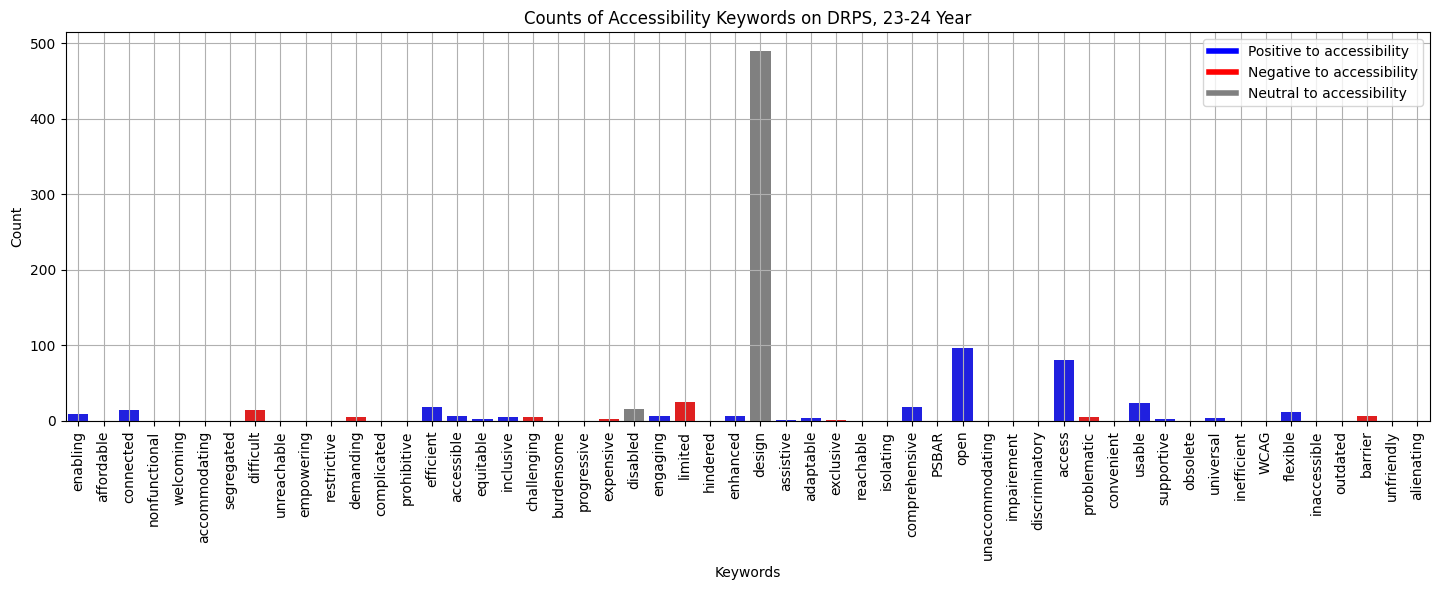

<Axes: title={'center': 'Counts of Accessibility Keywords on DRPS, 23-24 Year'}, xlabel='Keywords', ylabel='Count'>

In [2]:
# Example usage
directory = os.path.join(DIR_DATACONTAINER, DATA_VERSION)
plot_keyword_counts(directory, accessibility_dict['positive'], accessibility_dict['negative'])

#### Count the number of course containing accessibility information in 
 - "Summary", 
 - "Course description", 
 - "Learning Outcomes", 
 - "Graduate Attributes and Skills", 
 - "Keywords"

*Note: the semantic meaning analysis is done by Chatgpt-3.5 turbo*

In [3]:
# get number of courses in dic
data_version_dic = "./data_container/24_11_27_19_20_30/"
schoolurl_ls = os.listdir(data_version_dic)
schoolname_ls = [schoolurl_dic['_'.join(i.split('_')[1:]).replace('.csv', '')] for i in schoolurl_ls]

# initial dic - full database containing all three schools
school_dic = {}
df_ls = []
for school, schoolid in zip(schoolurl_ls, schoolname_ls):
    df = pd.read_csv(os.path.join(data_version_dic, school), usecols=lambda column : column != 'Unnamed: 0')
    df["School"] = schoolid
    school_dic[schoolid] = df.copy()
    df_ls.append(school_dic[schoolid])
full_df = pd.concat(df_ls, axis=0, ignore_index=True)

In [4]:
print(full_df.shape)
full_df.head()

(341, 9)


,URL,YEAR,Summary,Course description,Learning Outcomes,Graduate Attributes and Skills,Keywords,Course title,School
0,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08026...,24-25,This is a core course in year 2 of the Bachelo...,This course aims to provide students with an u...,"On completion of this course, the student will...",This course will stimulate the students curios...,"Research methods,nursing research",Evidence and Enquiry: Research (NUST08026),School of Health in Social Science
1,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08024...,24-25,This is a core course in year 2 of the Bachelo...,Building on the theory and practice-based lear...,"On completion of this course, the student will...","The ability to employ skills to gather, organi...","Community Social care,Health improvement,Behav...","Healthy Communities: Society, Culture and Heal...",School of Health in Social Science
2,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08025...,24-25,This is a core course in year 2 of the Bachelo...,The course builds on theory introduced in year...,"On completion of this course, the student will...",This course develops creative problem solvers ...,"E-Health,Digital enhancement & development,Hea...","Innovations in healthcare: Society, Culture an...",School of Health in Social Science
3,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08022...,24-25,This course is a year 2 core course within the...,Aims: The course aims to \n - provide students...,"On completion of this course, the student will...",This course contributes to the development of ...,"Mental health,nursing,communication,interperso...",Mental Health: Life Sciences and Nursing Care ...,School of Health in Social Science
4,http://www.drps.ed.ac.uk/24-25/dpt/cxnust08023...,24-25,This course includes clinical teaching and cli...,Outline content\nThis course will follow the s...,"On completion of this course, the student will...",This course will stimulate students' curiosity...,"Bioscience,pathology,pharmacology,clinical nur...",Mind and Body: Life Sciences and Nursing Care ...,School of Health in Social Science


In [13]:
col_order = ["YEAR", "School", "Course title", "Summary", "Course description", "Learning Outcomes", "Graduate Attributes and Skills", "Keywords", "URL"]
full_df = full_df[col_order]

In [ ]:
match_condition_list = ["accessi", "inclusi", "empath", "disabi", "WCAG", "Web Content Accessibility guidelines", "universal design", "design for all"]
scope_ls = ["Summary", "Course description", "Graduate Attributes and Skills", "Learning Outcomes"]
print(f"Use regular expression for searching.")
courses_contain_any_of_keywords = set()
for scope in scope_ls:
    print(f"\n------Looking into: scope of {scope}------")
    for condition in match_condition_list:
        subdf = full_df[full_df[scope].str.contains(condition,case=False, na=False, regex=True)]
        print(f"\t{len(subdf)} number of courses match the condition {condition}.")
        courses = subdf["Course title"].to_list()
        courses_contain_any_of_keywords = courses_contain_any_of_keywords | set(courses)
        if len(courses) > 0:
            print(f"\tThese courses are {courses}")

info_courses_contain_any_of_keywords = full_df[full_df['Course title'].isin(list(courses_contain_any_of_keywords))]

Use regular expression for searching.

------Looking into: scope of Summary------
	0 number of courses match the condition accessi.
	2 number of courses match the condition inclusi.
	These courses are ['Homeless and Inclusion Health: Global Challenges; Local Perspectives (NUST10051)', 'Homeless and Inclusion Health (NUST11093)']
	1 number of courses match the condition empath.
	These courses are ['Caring and Emotional Work (NUST10005)']
	2 number of courses match the condition disabi.
	These courses are ['Innovations in healthcare: Society, Culture and Health 2 (NUST08025)', 'Sport and Exercise Medicine 4 (SPRT10027)']
	0 number of courses match the condition WCAG.
	0 number of courses match the condition Web Content Accessibility guidelines.
	0 number of courses match the condition universal design.
	0 number of courses match the condition design for all.

------Looking into: scope of Course description------
	4 number of courses match the condition accessi.
	These courses are ['Disse

,YEAR,School,Course title,Summary,Course description,Learning Outcomes,Graduate Attributes and Skills,Keywords,URL
1,24-25,School of Health in Social Science,"Healthy Communities: Society, Culture and Heal...",This is a core course in year 2 of the Bachelo...,Building on the theory and practice-based lear...,"On completion of this course, the student will...","The ability to employ skills to gather, organi...","Community Social care,Health improvement,Behav...",http://www.drps.ed.ac.uk/24-25/dpt/cxnust08024...
2,24-25,School of Health in Social Science,"Innovations in healthcare: Society, Culture an...",This is a core course in year 2 of the Bachelo...,The course builds on theory introduced in year...,"On completion of this course, the student will...",This course develops creative problem solvers ...,"E-Health,Digital enhancement & development,Hea...",http://www.drps.ed.ac.uk/24-25/dpt/cxnust08025...
3,24-25,School of Health in Social Science,Mental Health: Life Sciences and Nursing Care ...,This course is a year 2 core course within the...,Aims: The course aims to \n - provide students...,"On completion of this course, the student will...",This course contributes to the development of ...,"Mental health,nursing,communication,interperso...",http://www.drps.ed.ac.uk/24-25/dpt/cxnust08022...
13,24-25,School of Health in Social Science,Caring and Emotional Work (NUST10005),The main focus of this course is on interperso...,Not entered,Critically appriase the literature on caring\n...,Not entered,"caring,emotions,empathy,relationships.",http://www.drps.ed.ac.uk/24-25/dpt/cxnust10005...
21,24-25,School of Health in Social Science,Global Public Health: Principles and Practice ...,"In a rapidly changing world, health is determi...",This course will challenge students to underst...,"On completion of this course, the student will...",* To be able to critically review ideas and co...,"Global Public Health,Nursing,Health Improvement",http://www.drps.ed.ac.uk/24-25/dpt/cxnust10045...
22,24-25,School of Health in Social Science,Homeless and Inclusion Health: Global Challeng...,This undergraduate course aims to develop in s...,The course will be taught over 10 weeks and wi...,"On completion of this course, the student will...","Students will work on, develop and evidence th...","Homelessness,health,inclusion,destitution,refu...",http://www.drps.ed.ac.uk/24-25/dpt/cxnust10051...
25,24-25,School of Health in Social Science,"Movement, Activity and Participation (NUST10046)",This course will consider the physiology of no...,This course will consider the physiology of no...,"On completion of this course, the student will...",To be able to critically review ideas and conc...,"Movement disorders,Activity,Participation,Reha...",http://www.drps.ed.ac.uk/24-25/dpt/cxnust10046...
26,24-25,School of Health in Social Science,Nursing people with complex needs: Life Scienc...,This course is a core course in year 3 of the ...,Academic Description\nThis course is a core co...,"On completion of this course, the student will...","Critical thinking and critical writing, presen...","Complex needs,co-morbidity,transitions",http://www.drps.ed.ac.uk/24-25/dpt/cxnust10053...
54,24-25,School of Health in Social Science,Dissertation by ePortfolio (NUST11089),This course is set to enable MSc students who ...,This course is set to enable MSc students who ...,"On completion of this course, the student will...",Ability to critically review and reflect on ad...,"ePortfolio,Nursing,Reflective practice",http://www.drps.ed.ac.uk/24-25/dpt/cxnust11089...
55,24-25,School of Health in Social Science,Dissertation: E-Portfolio (Online) (NUST11107),This course is set to enable MSc students who ...,This course is set to enable MSc students who ...,"On completion of this course, the student will...","At the end of this course, students will demon...","Dissertation,Research,Qualitative,Quantitative",http://www.drps.ed.ac.uk/24-25/dpt/cxnust11107...


In [ ]:
from IPython.display import display, HTML
def highlight_keywords(sentence, keywords):
    if isinstance(sentence, str):  # Check if the cell is a string
        for keyword in keywords:
            # Highlight keywords (case-insensitive)
            sentence = re.sub(
                rf"({keyword})", 
                r'<span style="background-color: yellow; font-weight: bold;">\1</span>',
                sentence, 
                flags=re.IGNORECASE
            )
    return sentence
highlighted_info_courses_contain_any_of_keywords = info_courses_contain_any_of_keywords.map(lambda cell: highlight_keywords(cell, match_condition_list))
info_courses_contain_any_of_keywords
info_courses_contain_any_of_keywords.to_csv("./info_of_courses_contain_keywords.csv", index=None)
display(HTML(highlighted_info_courses_contain_any_of_keywords.to_html(escape=False)))

/tmp/ipykernel_700568/2697206871.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  highlighted_info_courses_contain_any_of_keywords = info_courses_contain_any_of_keywords.applymap(lambda cell: highlight_keywords(cell, match_condition_list))


,YEAR,School,Course title,Summary,Course description,Learning Outcomes,Graduate Attributes and Skills,Keywords,URL
1,24-25,School of Health in Social Science,"Healthy Communities: Society, Culture and Health 2 (NUST08024)","This is a core course in year 2 of the Bachelor of Nursing with Honours (Adult) programme. It has a focus on the health of communities as part of a larger society. It builds on the student's knowledge and understanding of the impact which community and family dynamics can have on the health of an individual. This course aims to further develop the student's understanding of social, political and individual factors to examine how health and wellbeing in communities is shaped within contemporary society. The course content is delivered through a series of lectures and workshops and is suitable for health and social care students who have studied What is health?: Society, culture and health 1 in year 1 or study with equivalent learning outcomes.","Building on the theory and practice-based learning of the year 1 course, What is health?: Society, culture and health 1, this course further develops and deepens the student's knowledge of concepts related to health and wellbeing of the individual in the context of the family and wider community health. Students are enabled to develop a critical understanding about communities and how communities are engaged and motivated to undertake change to benefit the health of the wider population beyond that of the individual and the family.\n\nThis course will provide students with the opportunity to explore the principal theories, concepts and terminology of sociology relevant to health. Health promotion and education including teaching methods and learning styles that support change management will be developed with the students. Students' understanding of social and health legislation which is essential for nursing work in contemporary health and social care environments of today will also be further developed. Students will be able to support and enable people at all stages of life to make informed choices about how to manage health challenges in order to maximise their quality of life and improve health outcomes.\n\nEmploying taught theories and techniques, students are enabled to develop skills to start to assess and address health and social care needs of communities. The course addresses:\n\nAssessing the needs of a community\nCommunity development and enablement\nHealth inequalities and social inclusion\nThe principles of public health and health promotion\n\nCourse Aims\nTo provide students with knowledge about the diversity of communities and the impact this has on health, health needs and the approach taken in health and social care to address health need.\nTo promote the student's skills and knowledge base in assessing need, planning interventions and understanding approaches to evaluating impact and outcome.\n\nThis course will be taught over 10 weeks and will consist of 10x2hour classroom sessions. \n\nThis course will be taught as face-to-face delivery by a range of experts from within the School of Health in Social Science and also external health and social care practitioners. Students are expected to engage in their learning through group discussions, lectures and by reading relevant scholarly literature.","On completion of this course, the student will be able to:\n \nReflect on and discuss the complex nature of providing care in the community context.Assess and define the health needs of a specific community for the purposes of change management.Formulate an action plan for health improvement activities for addressing the health needs of a community.Demonstrate understanding and interpret current health and social care policies and legislation and practice in accordance with these and the NMC code.Discuss the important role health and social care practitioners have in enabling individuals to self-care when living with a long-term condition.","The ability 